In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge
import site_archive_nci

import shap

In [2]:
model = xgb.XGBRegressor()
# model.load_model("/scratch/er8/cd3022/xgb_models/test_model.json")
model.load_model("/scratch/er8/cd3022/xgb_models/radiance_model.json")

In [3]:
# data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_gridpoint_2024-01.parquet')
data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_radiances_2025-01-01+5.parquet')

In [4]:
X = data.drop(columns=['surface_global_irradiance'])
for n in range(1, 11):
    X = X.drop(columns=[f'surface_global_irradiance_t{n}'])
y = data['surface_global_irradiance_t6']

In [5]:
importance = model.feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print(feat_importance)

channel_0003_scaled_radiance           0.346378
solar_elevation                        0.316608
channel_0011_brightness_temperature    0.122154
channel_0013_brightness_temperature    0.085562
channel_0015_brightness_temperature    0.058493
channel_0008_brightness_temperature    0.048533
channel_0004_scaled_radiance           0.022272
dtype: float32


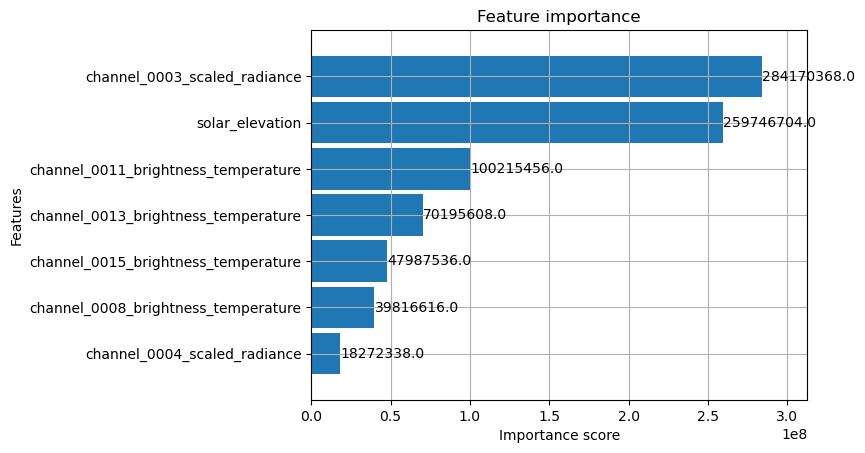

In [6]:
_ = xgb.plot_importance(model, height=0.9, importance_type="gain")

In [10]:
explainer = shap.Explainer(model)

idx = np.random.choice(len(X), size=20000, replace=False)
X_sample = X.iloc[idx]

shap_values = explainer(X_sample)

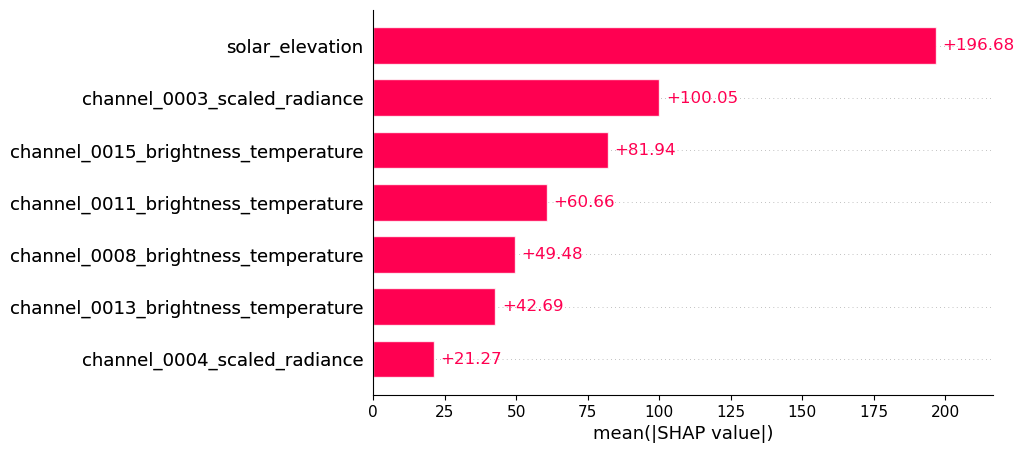

In [11]:
shap.plots.bar(shap_values)

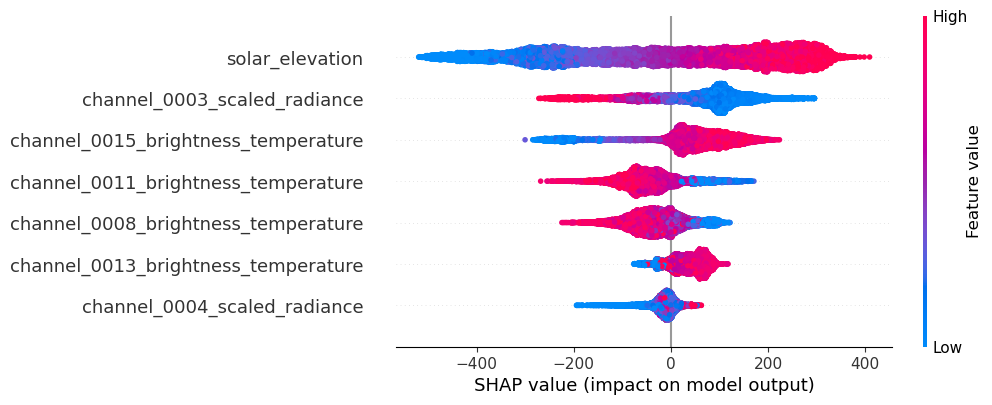

In [12]:
shap.plots.beeswarm(shap_values)